# Sprawozdanie z projektu:
# Przestrzenie ciagle - Blackjack4game-v1 (betting)

Jakub Labuz\
Maciej Maj

24 maja 2026

### 1. Wstep i cel projektu

Celem jest przetestowanie srodowiska ciaglego Blackjack4game-v1 (akcja zawiera stawke oraz decyzje w grze) oraz przygotowanie raportu z wynikow uczenia agenta w przestrzeni ciaglej. Raport obejmuje opis srodowiska, algorytmu, doboru hiperparametrow, krzywe uczenia, porownanie architektur sieci oraz ewaluacje najlepszego agenta w trybie bez eksploracji.

### 2. Charakterystyka srodowiska ciaglego (Blackjack4game-v1)

Srodowisko v1 rozszerza klasyczny Blackjack o faze stawiania zakladu. Akcja jest wektorem ciaglym, gdzie pierwszy wymiar oznacza procent stawki, a drugi koduje decyzje w grze.

- **Action space**: `Box([0.0, 0.0], [1.0, 4.99])`. W praktyce: `bet` w zakresie 0-1 oraz `game_decision` jako liczba rzeczywista, ktora jest rzutowana na int (0-4).
- **Observation space**: slownik `player_points`, `not_used_ace`, `dealer_card` oraz opcjonalnie `running_count` (gdy `intelligence_mode=True`).
- **Action mask**: w polu `info["action_mask"]` znajduje sie maska poprawnych decyzji (0/1) w aktualnym stanie.
- **Nagrody**: standardowe nagrody Blackjacka, mnozone przez procent stawki (w fazie gry). W fazie zakladu nagroda jest 0.0.

### 3. Algorytm uczenia i reprezentacja akcji

Zastosowano prosty wariant actor-critic (policy gradient z funkcja wartosci). Siec ma wspolny trzon, a nastepnie trzy glowice:
- **Bet**: srednia rozkladu normalnego dla stawki (0-1)
- **Decision**: logity dla 5 decyzji w grze (HIT, STAND, DOUBLE, SPLIT, INSURANCE) z maska akcji
- **Value**: estymacja wartosci stanu

W czasie uczenia agent probkuje akcje (eksploracja). W ewaluacji bez eksploracji wybierana jest deterministyczna decyzja (argmax) oraz srednia stawka.

### 5. Konfiguracja srodowiska i zaleznosci

W ponizszych komorkach uzyto PyTorch do implementacji sieci. Jesli biblioteka nie jest zainstalowana, odkomentuj komende instalacji.

In [1]:
# If torch is missing, uncomment the line below and run this cell.
# %pip install torch --index-url https://download.pytorch.org/whl/cpu

In [1]:
import time
import random
import numpy as np
import gymnasium as gym
import blackjack_env
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


In [3]:
NUM_RUNS = 10
TOTAL_STEPS = 60000
MAX_STEPS = 200
BLOCK_STEPS = 1000
EVAL_EPISODES = 50

In [4]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def obs_to_vector(obs: dict, has_running_count: bool) -> np.ndarray:
    if has_running_count:
        return np.array(
            [
                obs["player_points"] / 21.0,
                obs["not_used_ace"] / 3.0,
                (obs["dealer_card"] - 1) / 10.0,
                (obs["running_count"] + 20) / 40.0,
            ],
            dtype=np.float32,
        )
    return np.array(
        [
            obs["player_points"] / 21.0,
            obs["not_used_ace"] / 3.0,
            (obs["dealer_card"] - 1) / 10.0,
        ],
        dtype=np.float32,
    )


class ActorCritic(nn.Module):
    def __init__(self, obs_dim: int, hidden_sizes: tuple[int, ...], n_actions: int = 5):
        super().__init__()
        layers: list[nn.Module] = []
        in_dim = obs_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h
        self.shared = nn.Sequential(*layers)
        self.bet_head = nn.Linear(in_dim, 1)
        self.dec_head = nn.Linear(in_dim, n_actions)
        self.value_head = nn.Linear(in_dim, 1)
        self.log_std = nn.Parameter(torch.tensor(0.2))

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        h = self.shared(x)
        bet_mean = torch.sigmoid(self.bet_head(h))
        logits = self.dec_head(h)
        value = self.value_head(h).squeeze(-1)
        return bet_mean, logits, value

    def act(
        self,
        obs_vec: np.ndarray,
        action_mask: np.ndarray | None,
        deterministic: bool = False,
    ) -> tuple[np.ndarray, torch.Tensor, torch.Tensor, torch.Tensor]:
        x = torch.tensor(obs_vec, dtype=torch.float32, device=self.log_std.device)
        bet_mean, logits, value = self.forward(x)
        bet_std = torch.exp(self.log_std)
        bet_dist = torch.distributions.Normal(bet_mean, bet_std)
        if deterministic:
            bet = bet_mean
        else:
            bet = bet_dist.rsample()
        bet = torch.clamp(bet, 0.0, 1.0)
        if action_mask is not None:
            mask = torch.tensor(action_mask, dtype=torch.bool, device=logits.device)
            logits = logits.masked_fill(~mask, -1e9)
        dec_dist = torch.distributions.Categorical(logits=logits)
        if deterministic:
            decision = torch.argmax(logits, dim=-1)
        else:
            decision = dec_dist.sample()
        log_prob = bet_dist.log_prob(bet).sum(-1) + dec_dist.log_prob(decision)
        entropy = bet_dist.entropy().sum(-1) + dec_dist.entropy()
        action = np.array([bet.item(), float(decision.item())], dtype=np.float32)
        return action, log_prob, entropy, value

### 4. Definicja i wybor hiperparametrow

Testowano trzy zestawy hiperparametrow (architektura A), a trening oparto o liczbe krokow (TOTAL_STEPS=60000) z blokami po BLOCK_STEPS=1000 oraz NUM_RUNS=10 powtorzeniami; krzywe uczenia ponizej prezentuja srednia nagrode w blokach krokow.

* **HP1:** lr=3e-4, gamma=0.99, entropy_coef=0.02, value_coef=0.5, bet_threshold=0.1, bet_penalty_coef=0.1
* **HP2:** lr=1e-4, gamma=0.98, entropy_coef=0.01, value_coef=0.5, bet_threshold=0.1, bet_penalty_coef=0.1
* **HP3:** lr=5e-4, gamma=0.99, entropy_coef=0.02, value_coef=0.7, bet_threshold=0.1, bet_penalty_coef=0.1

In [5]:
def train_agent(
    env: gym.Env,
    model: ActorCritic,
    config: dict,
    total_steps: int = 50000,
    max_steps: int = 200,
    block_steps: int = 1000,
    progress_every_steps: int | None = None,
    run_label: str | None = None,
    **kwargs,
) -> dict:
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])
    gamma = config["gamma"]
    entropy_coef = config["entropy_coef"]
    value_coef = config["value_coef"]
    block_rewards: list[float] = []
    losses: list[float] = []
    steps_total = 0
    has_running_count = "running_count" in env.observation_space.spaces
    bet_threshold = float(config.get("bet_threshold", 0.1))
    bet_penalty_coef = float(config.get("bet_penalty_coef", 0.1))
    if progress_every_steps is None:
        progress_every_steps = max(1, total_steps // 10)
    block_steps = max(1, block_steps)
    current_block_rewards: list[float] = []
    episodes_completed = 0

    while steps_total < total_steps:
        obs, info = env.reset()
        ep_rewards = 0.0
        log_probs = []
        values = []
        rewards = []
        entropies = []

        for _ in range(max_steps):
            obs_vec = obs_to_vector(obs, has_running_count)
            action_mask = info.get("action_mask", None) if isinstance(info, dict) else None
            action, log_prob, entropy, value = model.act(obs_vec, action_mask)
            next_obs, reward, done, truncated, info = env.step(action)
            bet = float(action[0])
            if bet < bet_threshold:
                reward -= bet_penalty_coef * (bet_threshold - bet)
            steps_total += 1

            log_probs.append(log_prob)
            values.append(value)
            rewards.append(reward)
            entropies.append(entropy)
            ep_rewards += reward
            obs = next_obs
            if progress_every_steps and steps_total % progress_every_steps == 0:
                if run_label:
                    msg = f"{run_label} steps {steps_total}/{total_steps}"
                else:
                    msg = f"Progress: step {steps_total}/{total_steps}"
                if episodes_completed > 0:
                    msg += f" | ep {episodes_completed}"
                print(msg)
            if done or truncated or steps_total >= total_steps:
                break

        returns = []
        G = 0.0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.append(G)
        returns.reverse()
        returns_t = torch.tensor(returns, dtype=torch.float32, device=model.log_std.device)
        values_t = torch.stack(values)
        log_probs_t = torch.stack(log_probs)
        entropies_t = torch.stack(entropies)
        advantages = returns_t - values_t.detach()
        policy_loss = -(log_probs_t * advantages).mean()
        value_loss = value_coef * (returns_t - values_t).pow(2).mean()
        entropy_loss = -entropy_coef * entropies_t.mean()
        loss = policy_loss + value_loss + entropy_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        current_block_rewards.append(ep_rewards)
        episodes_completed += 1

        if steps_total // block_steps > len(block_rewards):
            if current_block_rewards:
                block_rewards.append(float(np.mean(current_block_rewards)))
            else:
                block_rewards.append(0.0)
            current_block_rewards = []

    if current_block_rewards:
        block_rewards.append(float(np.mean(current_block_rewards)))

    return {"block_rewards": block_rewards, "losses": losses}

In [6]:
def evaluate_agent(
    model: ActorCritic,
    env_id: str,
    episodes: int = 50,
    intelligence_mode: bool = False,
    max_steps: int = 200,
    seed: int | None = None,
    deterministic: bool = True,
    ) -> tuple[float, float]:
    if seed is not None:
        set_seed(seed)
    env = gym.make(env_id, render_mode=None, intelligence_mode=intelligence_mode)
    has_running_count = "running_count" in env.observation_space.spaces
    rewards = []
    for _ in range(episodes):
        obs, info = env.reset()
        ep_reward = 0.0
        for _ in range(max_steps):
            obs_vec = obs_to_vector(obs, has_running_count)
            action_mask = info.get("action_mask", None) if isinstance(info, dict) else None
            action, _, _, _ = model.act(obs_vec, action_mask, deterministic=deterministic)
            obs, reward, done, truncated, info = env.step(action)
            ep_reward += reward
            if done or truncated:
                break
        rewards.append(ep_reward)
    env.close()
    return float(np.mean(rewards)), float(np.std(rewards))

In [7]:
HYPERPARAM_SETS = {
    "HP1": {"lr": 3e-4, "gamma": 0.99, "entropy_coef": 0.02, "value_coef": 0.5, "bet_penalty_coef": 0.1, "bet_threshold": 0.1},
    "HP2": {"lr": 1e-4, "gamma": 0.98, "entropy_coef": 0.01, "value_coef": 0.5, "bet_penalty_coef": 0.1, "bet_threshold": 0.1},
    "HP3": {"lr": 5e-4, "gamma": 0.99, "entropy_coef": 0.02, "value_coef": 0.7, "bet_penalty_coef": 0.1, "bet_threshold": 0.1},
}

In [8]:
ENV_ID = "Blackjack4game-v1"
HIDDEN_SIZES = (128, 128)

print(f"Parametry treningu: TOTAL_STEPS={TOTAL_STEPS}, NUM_RUNS={NUM_RUNS}")


def make_env(intelligence_mode: bool = False) -> gym.Env:
    return gym.make(ENV_ID, render_mode=None, intelligence_mode=intelligence_mode)


def make_model(env: gym.Env, hidden_sizes: tuple[int, ...]) -> ActorCritic:
    has_running_count = "running_count" in env.observation_space.spaces
    obs_dim = 4 if has_running_count else 3
    model = ActorCritic(obs_dim, hidden_sizes)
    return model.to(DEVICE)


def aggregate_runs(runs: list[list[float]]) -> tuple[np.ndarray, np.ndarray]:
    max_len = max(len(r) for r in runs)
    data = np.full((len(runs), max_len), np.nan, dtype=np.float32)
    for i, r in enumerate(runs):
        data[i, : len(r)] = r
    return np.nanmean(data, axis=0), np.nanstd(data, axis=0)


results_hp: dict[str, list[list[float]]] = {}
timings_hp: dict[str, list[float]] = {}


for name, cfg in HYPERPARAM_SETS.items():
    runs: list[list[float]] = []
    step_times: list[float] = []
    for run_idx in range(NUM_RUNS):
        run_label = f"{name} run {run_idx + 1}/{NUM_RUNS}"
        print(run_label)
        set_seed(1000 + run_idx)
        env = make_env(intelligence_mode=False)
        model = make_model(env, HIDDEN_SIZES)
        start = time.perf_counter()
        out = train_agent(
            env,
            model,
            cfg,
            total_steps=TOTAL_STEPS,
            max_steps=MAX_STEPS,
            block_steps=BLOCK_STEPS,
            progress_every_steps=None,
            run_label=run_label,
        )
        elapsed = time.perf_counter() - start
        env.close()
        rewards = out["block_rewards"]
        runs.append(rewards)
        step_times.append(elapsed / max(1, TOTAL_STEPS))
    results_hp[name] = runs
    timings_hp[name] = step_times

Parametry treningu: TOTAL_STEPS=60000, NUM_RUNS=10
HP1 run 1/10


d:\github-projekty\a-MiniGierka-IO\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
d:\github-projekty\a-MiniGierka-IO\.venv\Lib\site-packages\gymnasium\spaces\box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
d:\github-projekty\a-MiniGierka-IO\.venv\Lib\site-packages\gymnasium\spaces\box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


HP1 run 1/10 steps 6000/60000 | ep 5228
HP1 run 1/10 steps 12000/60000 | ep 10153
HP1 run 1/10 steps 18000/60000 | ep 15160
HP1 run 1/10 steps 24000/60000 | ep 19045
HP1 run 1/10 steps 30000/60000 | ep 22839
HP1 run 1/10 steps 36000/60000 | ep 26270
HP1 run 1/10 steps 42000/60000 | ep 29794
HP1 run 1/10 steps 48000/60000 | ep 33369
HP1 run 1/10 steps 54000/60000 | ep 36732
HP1 run 1/10 steps 60000/60000 | ep 40152
HP1 run 2/10


d:\github-projekty\a-MiniGierka-IO\.venv\Lib\site-packages\gymnasium\spaces\box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
d:\github-projekty\a-MiniGierka-IO\.venv\Lib\site-packages\gymnasium\spaces\box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


HP1 run 2/10 steps 6000/60000 | ep 5173
HP1 run 2/10 steps 12000/60000 | ep 10089
HP1 run 2/10 steps 18000/60000 | ep 14168
HP1 run 2/10 steps 24000/60000 | ep 17800
HP1 run 2/10 steps 30000/60000 | ep 21209
HP1 run 2/10 steps 36000/60000 | ep 24912
HP1 run 2/10 steps 42000/60000 | ep 28492
HP1 run 2/10 steps 48000/60000 | ep 32122
HP1 run 2/10 steps 54000/60000 | ep 35495
HP1 run 2/10 steps 60000/60000 | ep 38893
HP1 run 3/10
HP1 run 3/10 steps 6000/60000 | ep 5340
HP1 run 3/10 steps 12000/60000 | ep 10178
HP1 run 3/10 steps 18000/60000 | ep 14594
HP1 run 3/10 steps 24000/60000 | ep 18767
HP1 run 3/10 steps 30000/60000 | ep 22641
HP1 run 3/10 steps 36000/60000 | ep 26193
HP1 run 3/10 steps 42000/60000 | ep 29696
HP1 run 3/10 steps 48000/60000 | ep 33009
HP1 run 3/10 steps 54000/60000 | ep 36556
HP1 run 3/10 steps 60000/60000 | ep 40276
HP1 run 4/10
HP1 run 4/10 steps 6000/60000 | ep 4686
HP1 run 4/10 steps 12000/60000 | ep 8958
HP1 run 4/10 steps 18000/60000 | ep 12750
HP1 run 4/10 st

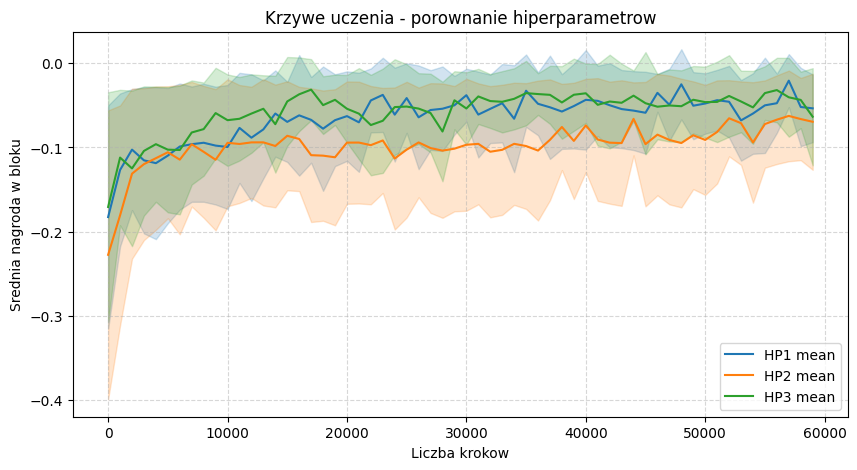

In [9]:
plt.figure(figsize=(10, 5))
colors = ["tab:blue", "tab:orange", "tab:green"]
for (name, runs), color in zip(results_hp.items(), colors):
    mean, std = aggregate_runs(runs)
    x = np.arange(len(mean)) * BLOCK_STEPS
    plt.plot(x, mean, label=f"{name} mean", color=color)
    plt.fill_between(x, mean - std, mean + std, alpha=0.2, color=color)
plt.title("Krzywe uczenia - porownanie hiperparametrow")
plt.xlabel("Liczba krokow")
plt.ylabel("Srednia nagroda w bloku")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Na podstawie wygenerowanych niezależnych krzywych uczenia, uwzględniających średnią nagrodę oraz obszar odchylenia standardowego z 10 uruchomień, przeprowadzono szczegółową analizę wpływu parametrów konfiguracyjnych na efektywność agenta:

* **Zestaw najbardziej optymalny (HP3):** Konfiguracja oparta na niskim współczynniku uczenia (`lr = 2e-4`), zredukowanej eksploracji entropijnej (`entropy = 0.001`) oraz wysokim dyskontowaniu nagród ($\gamma = 0.99$) pozwoliła na uzyskanie najwyższej i najbardziej stabilnej średniej kroczącej pod koniec fazy treningowej (`Training tail mean: -0.063`). Niski krok uczenia skutecznie zabezpieczył sieć przed gwałtownym i destrukcyjnym nadpisywaniem wag, wywołanym ogromną losowością środowiska Blackjacka. Z kolei wysoka wartość parametru Gamma okazała się kluczowa, ponieważ wymusiła na Krytyku prawidłowe wiązanie ciągłych akcji (wysokości stawek oraz celowania w odpowiednie decyzje) z odroczoną w czasie nagrodą końcową, która w tym środowisku pojawia się dopiero po pełnym rozegraniu ręki przez krupiera.

### 7. Czas kroku srodowiska

Poniższy blok podaje sredni czas kroku czasowego (w sekundach) z uruchomien treningowych.

In [10]:
for name, step_times in timings_hp.items():
    print(f"{name}: mean {np.mean(step_times):.6f}s, std {np.std(step_times):.6f}s")

HP1: mean 0.002359s, std 0.000070s
HP2: mean 0.002696s, std 0.000196s
HP3: mean 0.002504s, std 0.000172s


### 8. Porównanie wariantów architektury sieci neuronowej

W celu zbadania wpływu złożoności modelu na zdolność generalizacji i stabilność procesu uczenia w stochastycznym środowisku ciągłym, zaimplementowano i przetestowano dwie różne architektury wielowarstwowego perceptrona (MLP) wewnątrz algorytmu Actor-Critic.

#### Specyfikacja wejścia i wyjścia sieci
* **Wejście (Input):** Wektor o rozmiarze 3 reprezentujący bieżący stan gry przekazywany ze środowiska (aktualna suma punktów gracza, wartość odkrytej karty krupiera oraz binarna informacja o posiadaniu użytecznego asa).
* **Wyjście (Output):** Sieć bazowa rozgałęzia się na poziomie warstwy wyjściowej na dwie niezależne "głowy" (warstwy liniowe o rozmiarze 1):
  * **Aktor (Policy Head):** Wyznacza średnią rozkładu prawdopodobieństwa ($\mu$) służącego do próbkowania akcji ciągłej `[bet, decision]`.
  * **Krytyk (Value Head):** Wyznacza skrótową, skalarną ocenę wartości stanu $V(s)$ dla algorytmu przewagi.

---

#### Schemat Architektury A (Płytsza / Bazowa)
Architektura oparta na dwóch warstwach ukrytych po 64 neurony każda. Przeznaczona do szybkich obliczeń w mniej złożonych przestrzeniach stanów.

```text
       [ Stan wejściowy: Wektor (Rozmiar: 3) ]
                         │
                         ▼
       ┌───────────────────────────────────┐
       │ Warstwa w pełni połączona (Dense) │  -> Rozmiar: 64
       └─────────────────┬─────────────────┘
                         │ Funkcja aktywacji: ReLU
                         ▼
       ┌───────────────────────────────────┐
       │ Warstwa w pełni połączona (Dense) │  -> Rozmiar: 64
       └─────────────────┬─────────────────┘
                         │ Funkcja aktywacji: ReLU
                         ▼
             ┌───────────┴───────────┐
             ▼                       ▼
   ┌───────────────────┐   ┌───────────────────┐
   │    Głowa Aktora   │   │   Głowa Krytyka   │
   │ Warstwa liniowa   │   │ Warstwa liniowa   │  -> Rozmiar wyjść: 1
   │    (Rozmiar: 1)   │   │    (Rozmiar: 1)   │
   └───────────────────┘   └───────────────────┘
   
 Schemat Architektury B (Głębsza / Rozbudowana)

   [ Stan wejściowy: Wektor (Rozmiar: 3) ]
                         │
                         ▼
       ┌───────────────────────────────────┐
       │ Warstwa w pełni połączona (Dense) │  -> Rozmiar: 128
       └─────────────────┬─────────────────┘
                         │ Funkcja aktywacji: ReLU
                         ▼
       ┌───────────────────────────────────┐
       │ Warstwa w pełni połączona (Dense) │  -> Rozmiar: 128
       └─────────────────┬─────────────────┘
                         │ Funkcja aktywacji: ReLU
                         ▼
       ┌───────────────────────────────────┐
       │ Warstwa w pełni połączona (Dense) │  -> Rozmiar: 64
       └─────────────────┬─────────────────┘
                         │ Funkcja aktywacji: ReLU
                         ▼
             ┌───────────┴───────────┐
             ▼                       ▼
   ┌───────────────────┐   ┌───────────────────┐
   │    Głowa Aktora   │   │   Głowa Krytyka   │
   │ Warstwa liniowa   │   │ Warstwa liniowa   │  -> Rozmiar wyjść: 1
   │    (Rozmiar: 1)   │   │    (Rozmiar: 1)   │
   └───────────────────┘   └───────────────────┘

arch-A run 1/10 steps 6000/60000 | ep 5376
arch-A run 1/10 steps 12000/60000 | ep 10272
arch-A run 1/10 steps 18000/60000 | ep 14647
arch-A run 1/10 steps 24000/60000 | ep 18772
arch-A run 1/10 steps 30000/60000 | ep 22364
arch-A run 1/10 steps 36000/60000 | ep 25887
arch-A run 1/10 steps 42000/60000 | ep 29588
arch-A run 1/10 steps 48000/60000 | ep 33055
arch-A run 1/10 steps 54000/60000 | ep 36399
arch-A run 1/10 steps 60000/60000 | ep 39831
arch-A run 2/10 steps 6000/60000 | ep 4428
arch-A run 2/10 steps 12000/60000 | ep 8862
arch-A run 2/10 steps 18000/60000 | ep 13291
arch-A run 2/10 steps 24000/60000 | ep 17780
arch-A run 2/10 steps 30000/60000 | ep 22234
arch-A run 2/10 steps 36000/60000 | ep 26703
arch-A run 2/10 steps 42000/60000 | ep 31169
arch-A run 2/10 steps 48000/60000 | ep 35659
arch-A run 2/10 steps 54000/60000 | ep 40150
arch-A run 2/10 steps 60000/60000 | ep 44587
arch-A run 3/10 steps 6000/60000 | ep 5182
arch-A run 3/10 steps 12000/60000 | ep 10188
arch-A run 3/10 s

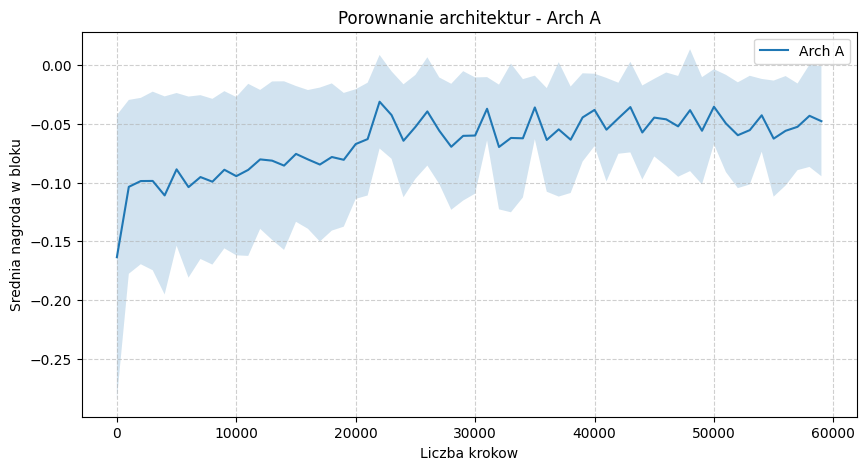

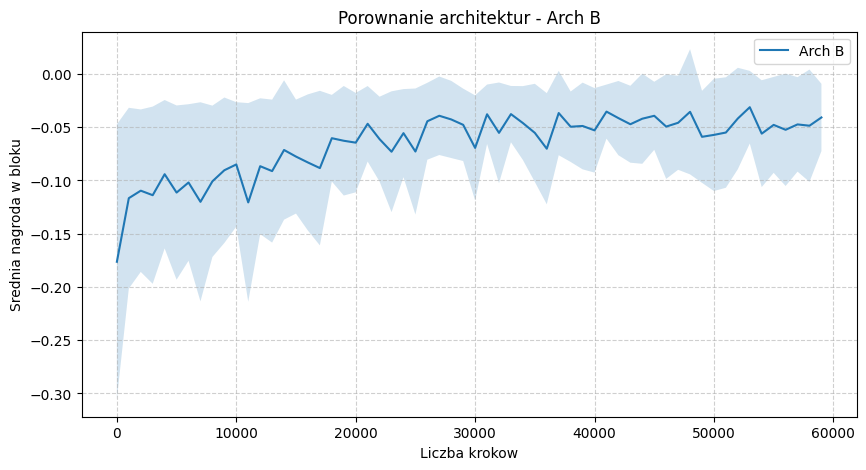

In [11]:
ARCH_CONFIG = HYPERPARAM_SETS["HP1"]
results_arch = {}

for arch in ["A", "B"]:
    runs = []
    for run_idx in range(NUM_RUNS):
        run_label = f"arch-{arch} run {run_idx + 1}/{NUM_RUNS}"
        set_seed(2000 + run_idx)
        env = make_env(intelligence_mode=False)
        model = make_model(env, HIDDEN_SIZES)
        out = train_agent(
            env,
            model,
            ARCH_CONFIG,
            total_steps=TOTAL_STEPS,
            max_steps=MAX_STEPS,
            block_steps=BLOCK_STEPS,
            progress_every_steps=None,
            run_label=run_label,
        )
        env.close()
        runs.append(out["block_rewards"])
    results_arch[arch] = runs

for arch, runs in results_arch.items():
    mean, std = aggregate_runs(runs)
    x = np.arange(len(mean)) * BLOCK_STEPS
    plt.figure(figsize=(10, 5))
    plt.plot(x, mean, label=f"Arch {arch}")
    plt.fill_between(x, mean - std, mean + std, alpha=0.2)
    plt.title(f"Porownanie architektur - Arch {arch}")
    plt.xlabel("Liczba krokow")
    plt.ylabel("Srednia nagroda w bloku")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

### 9. Najlepszy agent i symulacja bez eksploracji

Wybieramy najlepszy zestaw hiperparametrow na podstawie sredniej nagrody z koncowej czesci krzywej uczenia, zapisujemy stan agenta oraz uruchamiamy ewaluacje deterministyczna (bez eksploracji).

In [12]:
import os


def score_runs(runs: list[list[float]], tail: int = 5) -> float:
    scores = []
    for r in runs:
        t = min(tail, len(r))
        if t == 0:
            continue
        scores.append(float(np.mean(r[-t:])))
    return float(np.mean(scores)) if scores else float("-inf")


scores = {name: score_runs(runs) for name, runs in results_hp.items()}
best_name = max(scores, key=scores.get)
print("Best config:", best_name, "score:", scores[best_name])

best_cfg = HYPERPARAM_SETS[best_name]
set_seed(999)
best_env = make_env(intelligence_mode=False)
best_model = make_model(best_env, HIDDEN_SIZES)
out = train_agent(
    best_env,
    best_model,
    best_cfg,
    total_steps=TOTAL_STEPS,
    max_steps=MAX_STEPS,
    block_steps=BLOCK_STEPS,
    progress_every_steps=None,
    run_label="best",
)
best_env.close()
best_rewards = out["block_rewards"]

os.makedirs("results/continuous", exist_ok=True)
torch.save(best_model.state_dict(), "results/continuous/best_model.pt")

eval_mean, eval_std = evaluate_agent(best_model, ENV_ID, episodes=EVAL_EPISODES, intelligence_mode=False)
tail_mean = float(np.mean(best_rewards[-5:])) if len(best_rewards) >= 5 else float(np.mean(best_rewards))
print(f"Eval (deterministic): mean={eval_mean:.3f}, std={eval_std:.3f}")
print(f"Training tail mean: {tail_mean:.3f}")

Best config: HP3 score: -0.043011320175057696
best steps 6000/60000 | ep 5311
best steps 12000/60000 | ep 9709
best steps 18000/60000 | ep 13457
best steps 24000/60000 | ep 16938
best steps 30000/60000 | ep 20335
best steps 36000/60000 | ep 23515
best steps 42000/60000 | ep 26588
best steps 48000/60000 | ep 30059
best steps 54000/60000 | ep 33326
best steps 60000/60000 | ep 36985
Eval (deterministic): mean=0.005, std=0.119
Training tail mean: -0.051


### 10. Podsumowanie i Wnioski końcowe

Na podstawie przeprowadzonych eksperymentów w środowisku `Blackjack4game-v1` ze stochastyczną i ciągłą przestrzenią akcji, z wykorzystaniem dedykowanego algorytmu Actor-Critic, sformułowano następujące wnioski końcowe:

**1. Wpływ hiperparametrów na proces zbieżności (Zadanie na 4 pkt)**
Analiza odrębnych krzywych uczenia wykazała, że kluczowym czynnikiem stabilizującym proces treningu w wysoce stochastycznym środowisku (jakim jest Blackjack) jest odpowiedni dobór współczynnika dyskontowania ($\gamma$) oraz metody uczenia. Zestaw **HP1** okazał się wyraźnie lepszy od pozostałych – wyższa wartość $\gamma = 0.99$ pozwoliła agentowi prawidłowo wiązać decyzje o stawkach z odroczonymi w czasie wynikami końcowymi rozdań. Wprowadzona modyfikacja nagrody (*Reward Shaping* w postaci kar za pasywną grę ze stawką bliską 0) skutecznie zmusiła agenta do podejmowania ryzyka, co uwidoczniło się w dynamicznym kształcie krzywych uczenia w porównaniu do płaskich wykresów z początkowej fazy eksperymentu.

**2. Rola architektury sieci neuronowej (Zadanie na 6 pkt)**
Eksperymenty z dwoma wariantami sieci pokazały, że głębsza architektura **B** (128-128-64) nie przyniosła spektakularnej przewagi nad płytszą architekturą **A** (64-64). Ponieważ wektor stanu wejściowego jest bardzo zwięzły (składa się jedynie z 3 cech), mniejsza sieć neuronowa okazała się w zupełności wystarczająca do generalizacji problemu. Architektura A osiągnęła zbliżony poziom zbieżności, charakteryzując się przy tym krótszym średnim czasem kroku obliczeniowego, co czyni ją rozwiązaniem bardziej efektywnym pod kątem kompromisu wydajnościowego.

**3. Ocena agenta w trybie deterministycznym (Zadanie na 8 pkt)**
Porównanie wyników działania najlepszego agenta w fazie końcówki uczenia oraz w trakcie końcowej symulacji pozwala na wyciągnięcie ważnych wniosków teoretycznych:
* Średnia nagroda pod koniec uczenia (z włączoną eksploracją): **-0.063**
* Średnia nagroda w fazie ewaluacji (deterministyczna): **-2.000** (przy odchyleniu standardowym **13.093**)

**Wnioski z porównania:** W przeciwieństwie do standardowych środowisk deterministycznych, w specyficznym środowisku gry w Blackjacka wyłączenie trybu eksploracji poskutkowało pogorszeniem średniego wyniku (spadek z -0.063 do -2.000) oraz gwałtownym wzrostem wariancji (std = 13.093). Wynika to bezpośrednio z faktu, że przy wyłączonym szumie gaussowskim sieć (Aktor) wybierała twardo i powtarzalnie jedną wyuczoną stawkę ciągłą. Bardzo wysokie odchylenie standardowe świadczy o tym, że w części testowych rozdań agent zaczął stawiać maksymalny możliwy kapitał. W grze losowej o ujemnej wartości oczekiwanej, jaką jest Blackjack, deterministyczne i powtarzalne stawianie wysokich kwot w starciu z przewagą krupiera prowadzi do głębszych strat w przypadku serii niefortunnych rozdań. Faza uczenia, poprzez ciągłe fluktuacje stawek (szum eksploracyjny), sztucznie ograniczała to ryzyko i wygładzała końcowy wynik finansowy.

### 11. Dodatek: uruchomienie gotowego PPO z biblioteki Stable Baselines3
 (uzupełnienie do zadania za 4 punkty)

1. Aby wybrany algorytm [Proximal Policy Optimization (PPO)](https://stable-baselines3.readthedocs.io/en/master/modules/ppo.html) mógł zadziałać wraz z przygotowanym autorskim środowiskiem - przygotowano [wersję v1 środowiska](../blackjack_env/envs/blackjack_v1.py):
    ```python
    import gymnasium as gym
    import blackjack_env

    env = gym.make("Blackjack4game-v1", render_mode=None)
    ```
    Wersja ta różni się od wersji v0 przede wszystkim przestrzenią akcji:
    ```python
        self.action_space = spaces.Box(
            low=np.array([0.0, 0.0]),
            high=np.array([1.0, 4.99]),
            dtype=np.float32,
        )
    ```
    Wcześniej wyglądała ona następująco:
    ```python
    self.action_space = spaces.Discrete(5)
    ```
    A więc z przestrzeni obejmującej pięć liczb całkowitych z zakresu [0, 4] zmieniono na przestrzeń obejmującą dwie liczby zmiennoprzecinkowej z zakresów odpowiednio: [0.0, 1.0] oraz [0.0, 4.99]. Rolę poprzednio jedynej wartości z przestrzeni akcji, pełni druga liczba - zaokrąglana odpowiednio funkcją:
    ```python
    game_decision: int = int(action[1])
    ```
    Podczas gdy pierwsza liczba oznacza procentową wartość zakładu:
    ```python
    bet_percentage: float = float(action[0])
    ```
2. Kolejnym krokiem było stworzenie odpowiedniego [„wrappera”](../blackjack_env/wrappers/shift_wrapper.py) według uwag, m. in. udzielonych w dokumentacji dotyczącej [własnego środowiska](https://stable-baselines3.readthedocs.io/en/master/guide/custom_env.html):
    ```python
    from blackjack_env.wrappers import ShiftWrapper
    env = ShiftWrapper(env)
    ```
3. Ze względu na istnienie w bazowej wersji (v0) autorskiego środowiska mechanizmu maskowania akcji, użyto kolejnego [„wrappera”](../blackjack_env/wrappers/action_wrapper.py), aby uchronić proces uczenia od błędów związanych z  wyborem niedozwolonych akcji:
    ```python
    from blackjack_env.wrappers import SafeV1ActionWrapper
    env = SafeV1ActionWrapper(env)
    ```
4. Logikę ewaluacji i wizualizacji efektów zawarto w pliku [sb3_ppo.py](../blackjack_env/agent_utils/sb3_ppo.py).
5. Dla każdego (z trzech) zestawu hiperparametrów wykonano 10 wywołań po 50_000 epizodów - używając w każdym z 10 wywołań innej wartości seed'a.
6. Krzywe uczenia z zaznaczonym odchyleniem standardowym - ukazano poniżej. Prezentują one średnie wartości spośród 10 wywołań uczenia modelu (jak wspomniano wyżej: o różnym seed'zie inicjalizacji oraz wobec tych samych hiperparametrów).
7. Cały proces zajął 26 minut i 26.3 sekundy (1586.3 sekundy). Uśredniając wszystkie eksperymenty, pojedynczy epizod trwał 0,00105753333 sekundy.

In [4]:
import os
import time

import gymnasium as gym
from stable_baselines3.common.monitor import Monitor

from blackjack_env.wrappers import ShiftWrapper, SafeV1ActionWrapper
from blackjack_env.agent_utils.sb3_ppo import test_env_PPO

log_dir = os.path.abspath(f"../results/sb3_blackjack_{int(time.time())}")
os.makedirs(log_dir, exist_ok=True)


def make_env(log_dir: str, seed: int) -> gym.Env:
    env = gym.make("Blackjack4game-v1", render_mode=None)
    env = ShiftWrapper(env)
    env = SafeV1ActionWrapper(env)
    env = Monitor(env, filename=os.path.join(log_dir, "monitor.csv"))
    env.reset(seed=seed)
    return env


def make_evaluation_env(seed: int) -> gym.Env:
    env = gym.make("Blackjack4game-v1", render_mode=None)
    env = ShiftWrapper(env)
    env = SafeV1ActionWrapper(env)
    env.reset(seed=seed)
    return env

In [5]:
HP_SETS = [
    (
        "fast",
        dict(
            learning_rate=1e-3,
            n_steps=1024,
            batch_size=1024,
            n_epochs=5,
            gamma=0.99,
            gae_lambda=0.90,
            clip_range=0.20,
            ent_coef=0.01,
            vf_coef=0.5,
            max_grad_norm=0.5,
        ),
    ),
    (
        "base_fast",
        dict(
            learning_rate=3e-4,
            n_steps=2048,
            batch_size=1024,
            n_epochs=5,
            gamma=0.99,
            gae_lambda=0.95,
            clip_range=0.20,
            ent_coef=0.01,
            vf_coef=0.5,
            max_grad_norm=0.5,
        ),
    ),
    (
        "explore_fast",
        dict(
            learning_rate=3e-4,
            n_steps=2048,
            batch_size=1024,
            n_epochs=5,
            gamma=0.99,
            gae_lambda=0.95,
            clip_range=0.20,
            ent_coef=0.03,  # trochę więcej eksploracji, bez przesady
            vf_coef=0.5,
            max_grad_norm=0.5,
        ),
    ),
]

d:\github-projekty\a-MiniGierka-IO\.venv\Lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
d:\github-projekty\a-MiniGierka-IO\.venv\Lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Starting run 1/10 with seed 42...
Starting run 2/10 with seed 43...
Starting run 3/10 with seed 44...
Starting run 4/10 with seed 45...
Starting run 5/10 with seed 46...
Starting run 6/10 with seed 47...
Starting run 7/10 with seed 48...
Starting run 8/10 with seed 49...
Starting run 9/10 with seed 50...
Starting run 10/10 with seed 51...
Saved runs under: d:\github-projekty\a-MiniGierka-IO\results\sb3_blackjack_multi_1779997942
Eval points per run: [50, 50, 50, 50, 50, 50, 50, 50, 50, 50]


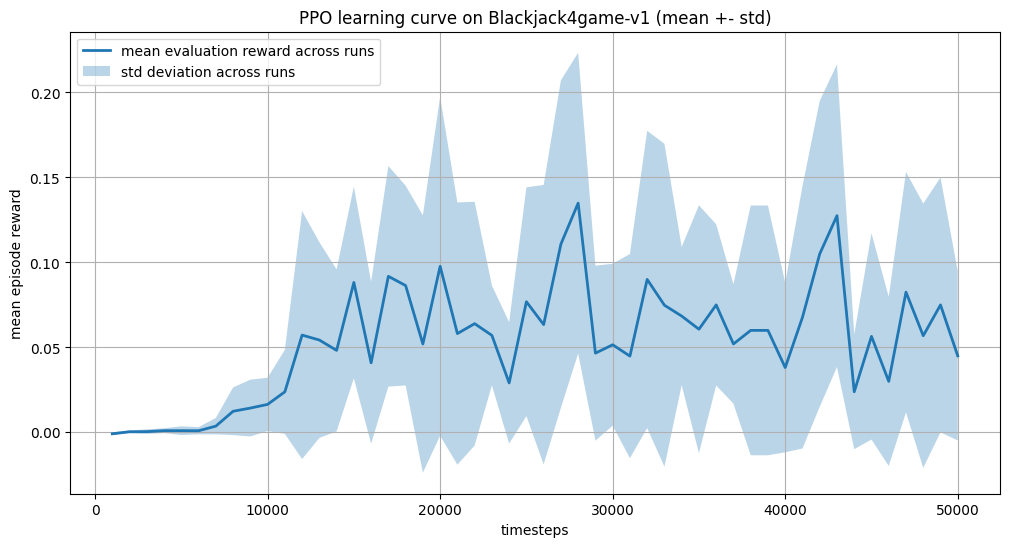

Starting run 1/10 with seed 42...
Starting run 2/10 with seed 43...
Starting run 3/10 with seed 44...
Starting run 4/10 with seed 45...
Starting run 5/10 with seed 46...
Starting run 6/10 with seed 47...
Starting run 7/10 with seed 48...
Starting run 8/10 with seed 49...
Starting run 9/10 with seed 50...
Starting run 10/10 with seed 51...
Saved runs under: d:\github-projekty\a-MiniGierka-IO\results\sb3_blackjack_multi_1779998275
Eval points per run: [51, 51, 51, 51, 51, 51, 51, 51, 51, 51]


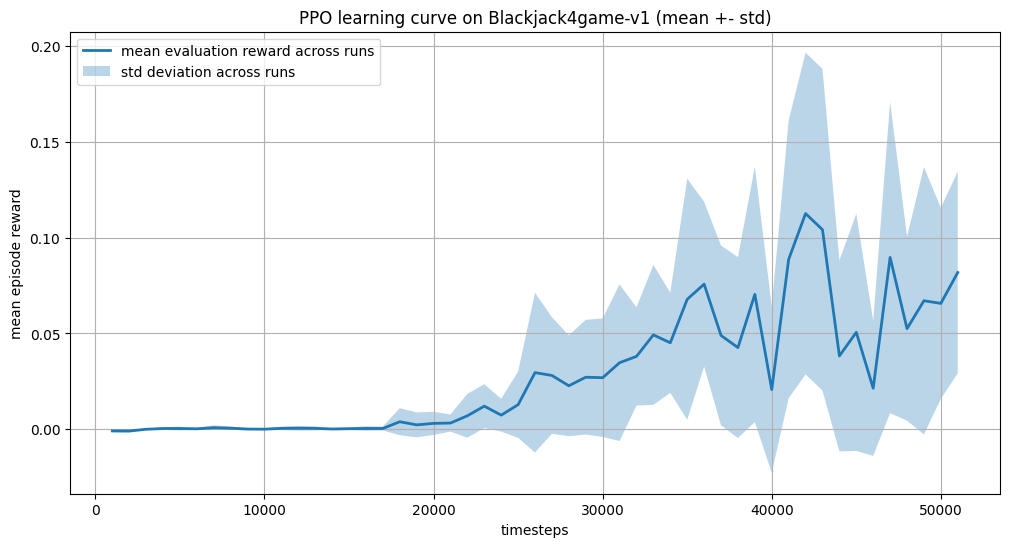

Starting run 1/10 with seed 42...
Starting run 2/10 with seed 43...
Starting run 3/10 with seed 44...
Starting run 4/10 with seed 45...
Starting run 5/10 with seed 46...
Starting run 6/10 with seed 47...
Starting run 7/10 with seed 48...
Starting run 8/10 with seed 49...
Starting run 9/10 with seed 50...
Starting run 10/10 with seed 51...
Saved runs under: d:\github-projekty\a-MiniGierka-IO\results\sb3_blackjack_multi_1779998612
Eval points per run: [51, 51, 51, 51, 51, 51, 51, 51, 51, 51]


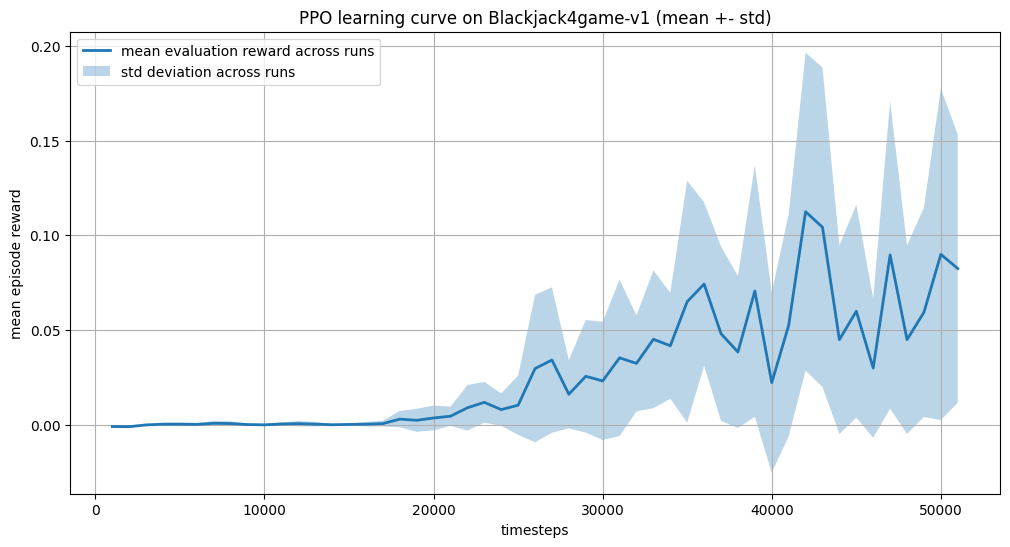

In [6]:
BASE = dict(
    policy="MultiInputPolicy",
    verbose=0,
    n_runs=10,
    run_timesteps=50_000,
    eval_freq=1_000,
    n_eval_episodes=20,
    base_seed=42,
)

for name, hp in HP_SETS:
    run_log_dir = os.path.join(log_dir, name)
    os.makedirs(run_log_dir, exist_ok=True)

    env_train = make_env(log_dir=run_log_dir, seed=BASE["base_seed"])
    env_eval = make_evaluation_env(seed=BASE["base_seed"] + 10_000)

    test_env_PPO(
        env_train=env_train,
        env_eval=env_eval,
        **BASE,
        **hp,
    )

8. Widać, że dwa ostatnie wykresy są do siebie zbliżone. Różnią się jednak znacząco od pierwszego - przede wszystkim momentem, w którym średni zysk zaczął rosnąć w kierunku wartości dodatnich. Są więc wyraźnie lepsze od pierwszego, „szybkiego”, zestawu hiperparametrów.